In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mpc

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
#station code
STNS = np.loadtxt("../DATA/Stations.txt",dtype='U2')
#station details
STN_LAT_LON = pd.read_csv("../DATA/Stations.csv", index_col=1) 
#different ET estimates
VNS = np.loadtxt("../DATA/Products.txt",dtype='<U10')

#data for eatch model for each station
STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc", engine = "netcdf4")

#errors for each model for each station
STN_ERR = xr.open_dataarray("../DATA/STN_ERR.nc", engine = "netcdf4")

#adaptive bias for each model for each station
STN_AB = xr.open_dataarray("../DATA/STN_AB.nc", engine = "netcdf4")

#error for each model for each station
STN_AB_ERR = xr.open_dataarray("../DATA/STN_AB_ERR.nc", engine = "netcdf4")

In [3]:
print(STNS)

['AY' 'BE' 'BT' 'CA' 'CS' 'CT' 'DY' 'FR' 'GN' 'JC' 'MC' 'MD' 'MH' 'MP'
 'MR' 'NT' 'OP' 'RP' 'SA' 'SI' 'VO']


In [4]:
print(STN_LAT_LON)

                     station_name     lat     lon
StationCode                                      
AY                        ATHENRY  53.289  -8.786
BE                     BALLYHAISE  54.051  -7.310
BT                      BELMULLET  54.228 -10.007
CA                       CASEMENT  53.306  -6.439
CS                    CLAREMORRIS  53.711  -8.993
CT                   CORK AIRPORT  51.847  -8.486
DY                        DUNSANY  53.516  -6.660
FR                         FINNER  54.494  -8.243
GN                        GURTEEN  53.035  -8.009
JC             JOHNSTOWN CASTLE 2  52.298  -6.497
MC                      MACE HEAD  53.326  -9.901
MH                     MALIN HEAD  55.372  -7.339
MP                     MOORE PARK  52.164  -8.264
MD                      MT DILLON  53.727  -7.981
MR                      MULLINGAR  53.537  -7.362
NT                        NEWPORT  53.924  -9.573
OP                       OAK PARK  52.861  -6.915
RP                   ROCHES POINT  51.793  -8.244


In [5]:
print(VNS)

['PM' 'AQUA' 'ERA5' 'GLDAS' 'GLEAM' 'JRA' 'LSA' 'MERRA' 'SSEBop' 'TERRA'
 'TH' 'WaPOR']


In [6]:
print(STN_DATA)

<xarray.DataArray 'ET' (Station: 21, Product: 12, datetime: 276)> Size: 556kB
[69552 values with dtype=float64]
Coordinates:
  * Station   (Station) <U2 168B 'AY' 'BE' 'BT' 'CA' ... 'RP' 'SA' 'SI' 'VO'
  * Product   (Product) <U6 288B 'AQUA' 'ERA5' 'GLDAS' ... 'TERRA' 'TH' 'WaPOR'
  * datetime  (datetime) datetime64[ns] 2kB 2018-01-01 2018-01-09 ... 2023-12-27


In [7]:
print(STN_ERR)

<xarray.DataArray 'ET' (Station: 21, Product: 12, datetime: 276)> Size: 556kB
[69552 values with dtype=float64]
Coordinates:
  * Station   (Station) <U2 168B 'AY' 'BE' 'BT' 'CA' ... 'RP' 'SA' 'SI' 'VO'
  * Product   (Product) <U6 288B 'AQUA' 'ERA5' 'GLDAS' ... 'TERRA' 'TH' 'WaPOR'
  * datetime  (datetime) datetime64[ns] 2kB 2018-01-01 2018-01-09 ... 2023-12-27


In [8]:
print(STN_AB)

<xarray.DataArray 'ET' (Station: 21, Product: 10, datetime: 273)> Size: 459kB
[57330 values with dtype=float64]
Coordinates:
  * Station   (Station) <U2 168B 'AY' 'BE' 'BT' 'CA' ... 'RP' 'SA' 'SI' 'VO'
  * Product   (Product) <U6 240B 'AQUA' 'ERA5' 'GLDAS' ... 'TERRA' 'WaPOR'
  * datetime  (datetime) datetime64[ns] 2kB 2018-01-25 2018-02-02 ... 2023-12-27


In [9]:
print(STN_AB_ERR)

<xarray.DataArray 'ET' (Station: 21, Product: 10, datetime: 273)> Size: 459kB
[57330 values with dtype=float64]
Coordinates:
  * Station   (Station) <U2 168B 'AY' 'BE' 'BT' 'CA' ... 'RP' 'SA' 'SI' 'VO'
  * Product   (Product) <U6 240B 'AQUA' 'ERA5' 'GLDAS' ... 'TERRA' 'WaPOR'
  * datetime  (datetime) datetime64[ns] 2kB 2018-01-25 2018-02-02 ... 2023-12-27


Drop PM and TH Products

In [10]:
O = STN_DATA.loc[dict(Product="PM")]
R = STN_DATA.drop_sel(Product=["PM", "TH"])
R_ERR = STN_ERR.drop_sel(Product=["PM", "TH"])

Sort absolute values of errors, from lowest to highest.

In [11]:
R_sort = np.abs(R_ERR).argsort(axis=1)
AB_sort = np.abs(STN_AB_ERR).argsort(axis=1)

Select the best product at each time step

In [12]:
R_best = R_sort[:,0,:]
AB_best = AB_sort[:,0,:]

Initialise array to hold counts for each station and product

In [13]:
R_count = R.mean(dim="datetime")*0
AB_count = STN_AB.mean(dim="datetime")*0

Count number of products bests for each station and write to array

In [14]:
for i in range(len(STNS)):
    stnv, stnc = np.unique(R_best[i,:], return_counts=True)
    R_count[i,stnv] = stnc
    stnv, stnc = np.unique(AB_best[i,:], return_counts=True)
    AB_count[i,stnv] = stnc

In [15]:
# Calculate percentages for each station
ab_percent_station = (AB_count / AB_count.sum(dim='Product')) * 100
r_percent_station = (R_count / R_count.sum(dim='Product')) * 100

# Convert to DataFrames
ab_percent_df = ab_percent_station.to_dataframe(name='AB_percent').reset_index()
r_percent_df = r_percent_station.to_dataframe(name='R_percent').reset_index()

# Merge the DataFrames
percent_table = pd.merge(ab_percent_df, r_percent_df, on=['Station', 'Product'])

# Pivot to create station-product matrix for each metric
ab_pivot = percent_table.pivot(index='Station', columns='Product', values='AB_percent')
r_pivot = percent_table.pivot(index='Station', columns='Product', values='R_percent')

# Combine into a multi-index DataFrame
combined_percent = pd.concat({'AB_percent': ab_pivot, 'R_percent': r_pivot}, axis=1)

# Sort columns to have AB_percent and R_percent next to each other for each product
combined_percent = combined_percent.sort_index(axis=1, level=[1,0])

# Format percentages with 1 decimal place
combined_percent = combined_percent.round(1)

In [16]:
# Calculate mean AB_percent across all stations for each product
ab_mean_percent = combined_percent['AB_percent'].mean(axis=0).round(1)

# Convert to DataFrame and sort
ab_summary = pd.DataFrame({
    'Product': ab_mean_percent.index,
    'AB_percent_mean': ab_mean_percent.values
}).sort_values('AB_percent_mean', ascending=False)

# Display
print("Average AB_percent across all stations:")
print(ab_summary.to_string(index=False))


Average AB_percent across all stations:
Product  AB_percent_mean
    LSA             20.2
  GLEAM             12.6
  WaPOR             10.1
    JRA             10.0
  GLDAS              8.6
  MERRA              8.4
   AQUA              7.8
  TERRA              7.7
 SSEBop              7.4
   ERA5              7.3


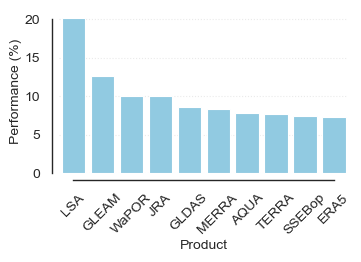

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up figure 0
plt.figure(figsize=(3.5, 2.5))
sns.set_style("white") 
sns.set_context("paper", font_scale=1)  

# Create the barplot with optimized parameters
ax = sns.barplot(data=ab_summary, 
                x='Product', 
                y='AB_percent_mean',
                color='skyblue',
                saturation=0.8,  
                order=ab_summary.sort_values('AB_percent_mean', ascending=False)['Product'])

# Adjust axis labels and ticks
plt.xlabel('Product', fontsize=10, labelpad=2)
plt.ylabel('Performance (%)', fontsize=10, labelpad=2)
ax.tick_params(axis='x', which='major', labelsize=10, rotation=45) 
ax.tick_params(axis='y', which='major', labelsize=10)

# Remove unnecessary chart junk
sns.despine(offset=5, trim=True) 
ax.grid(axis='y', linestyle=':', alpha=0.4)  

# Adjust layout and save
plt.tight_layout(pad=0.3)
plt.savefig("ET4I_COUNT.png", dpi=300, bbox_inches='tight')